# K-Moda MMM · Notebook 1: ETL

- Granularidad: **semanal nacional**
- Target: `venta_neta_total_eur` (suma semanal de `venta_neta_sin_iva_eur` desde `ventas_lineas`)
- Tráfico se incluye solo para EDA — NO entra en el modelo (son mediadores)
- Filtrado de semanas iniciales por **fecha**, no por índice

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

VERSION   = 1
DATA_LAKE = os.path.join("data", "lake")
WAREHOUSE = os.path.join("data", "warehouse")
OUT_DIR   = os.path.join(WAREHOUSE, f"version{VERSION}")
os.makedirs(OUT_DIR, exist_ok=True)

# ── K-Moda brand palette ─────────────────────────────────────────────────────
KM_GOLD      = "#C8A96E"
KM_GOLD_DARK = "#8B6914"
KM_CHARCOAL  = "#2D2D2D"
KM_CREAM     = "#F7F4EF"
KM_GRAY      = "#9E9893"
KM_IVORY     = "#EDE8DC"
KM_CHANNELS  = ["#C8A96E", "#8B6914", "#2D2D2D", "#9E9893",
                 "#D4C4A8", "#6B5B3E", "#B8A88A", "#5C4A2A"]

plt.rcParams.update({
    "figure.facecolor":  KM_CREAM,
    "axes.facecolor":    KM_CREAM,
    "axes.edgecolor":    KM_GRAY,
    "axes.labelcolor":   KM_CHARCOAL,
    "axes.titlecolor":   KM_CHARCOAL,
    "axes.titlesize":    12,
    "axes.titlepad":     12,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        KM_GRAY,
    "grid.alpha":        0.18,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.5,
    "xtick.color":       KM_GRAY,
    "ytick.color":       KM_GRAY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.7,
    "legend.edgecolor":  KM_GRAY,
    "figure.figsize":    (14, 4.5),
    "figure.dpi":        130,
    "savefig.facecolor": KM_CREAM,
    "savefig.bbox":      "tight",
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"K-Moda MMM · ETL · VERSION={VERSION}")
print(f"Output: {OUT_DIR}")

K-Moda MMM · ETL · VERSION=1
Output: data/warehouse/version1


## 1. Carga de datos

In [2]:
clientes  = pd.read_csv(os.path.join(DATA_LAKE, "clientes.csv"))
productos = pd.read_csv(os.path.join(DATA_LAKE, "productos.csv"))
calendario= pd.read_csv(os.path.join(DATA_LAKE, "calendario_ciudad.csv"))
trafico   = pd.read_csv(os.path.join(DATA_LAKE, "trafico_tienda_web_diario.csv"))
inversion = pd.read_csv(os.path.join(DATA_LAKE, "inversion_medios_semanal.csv"))
pedidos   = pd.read_csv(os.path.join(DATA_LAKE, "pedidos.csv"))
ventas    = pd.read_csv(os.path.join(DATA_LAKE, "ventas_lineas.csv"))

for name, df in [("clientes",clientes),("productos",productos),("calendario",calendario),
                 ("trafico",trafico),("inversion",inversion),("pedidos",pedidos),
                 ("ventas_lineas",ventas)]:
    print(f"  ✓ {name:15s} → {df.shape[0]:>10,} filas × {df.shape[1]:>2} cols")

  ✓ clientes        →    600,000 filas ×  9 cols
  ✓ productos       →        510 filas ×  9 cols
  ✓ calendario      →     18,270 filas × 18 cols
  ✓ trafico         →     18,270 filas × 18 cols
  ✓ inversion       →     20,880 filas ×  9 cols
  ✓ pedidos         →  8,000,000 filas ×  9 cols
  ✓ ventas_lineas   →  8,000,000 filas × 15 cols


## 2. Normalización de fechas a lunes ISO

Cualquier fecha → lunes de su semana. Todas las tablas se alinean a la misma rejilla temporal antes de cualquier JOIN.

In [3]:
def to_semana_inicio(date_series: pd.Series) -> pd.Series:
    """Devuelve el lunes (00:00) de la semana ISO de cada fecha."""
    d = pd.to_datetime(date_series)
    return (d - pd.to_timedelta(d.dt.dayofweek, unit="D")).dt.normalize()

ventas["semana_inicio"]     = to_semana_inicio(ventas["fecha_venta"])
pedidos["semana_inicio"]    = to_semana_inicio(pedidos["fecha_pedido"])
calendario["semana_inicio"] = to_semana_inicio(calendario["fecha"])
trafico["semana_inicio"]    = to_semana_inicio(trafico["fecha"])
inversion["semana_inicio"]  = to_semana_inicio(inversion["semana_inicio"])

print("Rango temporal:")
print(f"  ventas    : {ventas['semana_inicio'].min().date()} → {ventas['semana_inicio'].max().date()}")
print(f"  pedidos   : {pedidos['semana_inicio'].min().date()} → {pedidos['semana_inicio'].max().date()}")
print(f"  inversion : {inversion['semana_inicio'].min().date()} → {inversion['semana_inicio'].max().date()}")
print(f"  calendario: {calendario['semana_inicio'].min().date()} → {calendario['semana_inicio'].max().date()}")
print(f"  trafico   : {trafico['semana_inicio'].min().date()} → {trafico['semana_inicio'].max().date()}")

Rango temporal:
  ventas    : 2019-12-30 → 2024-12-30
  pedidos   : 2019-12-30 → 2024-12-30
  inversion : 2020-01-06 → 2024-12-30
  calendario: 2019-12-30 → 2024-12-30
  trafico   : 2019-12-30 → 2024-12-30


## 3. Ventas semanales (target Yₜ)

Agregación nacional desde `ventas_lineas`. **`venta_neta_sin_iva_eur` es la semilla del target** (PDF §3.1). Sumamos también coste para EDA, pero NO se usa en el modelo.

In [4]:
ventas_weekly = (
    ventas
    .groupby("semana_inicio", as_index=False)
    .agg(
        venta_neta_total_eur       = ("venta_neta_sin_iva_eur", "sum"),
        coste_produccion_total_eur = ("coste_produccion_eur",   "sum"),
        unidades_vendidas          = ("cantidad_unidades",      "sum"),
        n_lineas                   = ("id_linea",               "count"),
        n_clientes_unicos          = ("id_cliente",             "nunique"),
        descuento_medio_pct        = ("descuento_pct",          "mean"),
        pct_lineas_con_descuento   = ("descuento_pct",          lambda x: (x > 0).mean() * 100),
    )
)
print(f"Ventas semanales: {len(ventas_weekly):,} filas")
ventas_weekly.head(4)

Ventas semanales: 262 filas


,semana_inicio,venta_neta_total_eur,coste_produccion_total_eur,unidades_vendidas,n_lineas,n_clientes_unicos,descuento_medio_pct,pct_lineas_con_descuento
0,2019-12-30,"1,289,866.76","502,214.77",33533,13424,13282,3.92,29.66
1,2020-01-06,"1,744,807.79","681,185.37",45706,18287,17999,4.04,30.26
2,2020-01-13,"1,743,767.43","681,370.53",45483,18240,17986,4.00,29.91
3,2020-01-20,"1,748,775.45","683,008.61",45595,18168,17914,4.01,30.27


## 4. Pedidos semanales (ticket medio correcto)

`ticket_medio_eur` debe calcularse a nivel **carrito** (PEDIDOS), no a nivel línea. Si lo calculáramos como media de líneas, infláramos el ticket porque cada cliente compra varias líneas.

In [5]:
pedidos_weekly = (
    pedidos
    .groupby("semana_inicio", as_index=False)
    .agg(
        n_pedidos              = ("id_pedido",                "nunique"),
        importe_neto_total_eur = ("importe_neto_sin_iva_eur", "sum"),
    )
)
pedidos_weekly["ticket_medio_eur"] = (
    pedidos_weekly["importe_neto_total_eur"] / pedidos_weekly["n_pedidos"]
)
print(f"Pedidos semanales: {len(pedidos_weekly):,} filas")
pedidos_weekly.head(4)

Pedidos semanales: 262 filas


,semana_inicio,n_pedidos,importe_neto_total_eur,ticket_medio_eur
0,2019-12-30,13424,"1,289,866.76",96.09
1,2020-01-06,18287,"1,744,807.79",95.41
2,2020-01-13,18240,"1,743,767.43",95.60
3,2020-01-20,18168,"1,748,775.45",96.26


## 5. Inversión: pivot por canal a nivel nacional

Pivote por `canal_medio` y suma de `inversion_eur` a través de las 10 ciudades. Genera 8 columnas `inv_*` que son el vector Xₜ,ₘ del MMM (PDF §2.1).

In [6]:
def canal_to_col(canal: str) -> str:
    return "inv_" + canal.lower().replace(" ", "_")

inv_weekly = (
    inversion
    .pivot_table(
        index      = "semana_inicio",
        columns    = "canal_medio",
        values     = "inversion_eur",
        aggfunc    = "sum",
        fill_value = 0,
    )
    .reset_index()
)
inv_weekly.columns.name = None
inv_weekly = inv_weekly.rename(
    columns=lambda c: c if c == "semana_inicio" else canal_to_col(c)
)
inv_weekly["inversion_total_eur"] = inv_weekly.drop(columns="semana_inicio").sum(axis=1)

print(f"Inversión semanal: {len(inv_weekly):,} filas × {inv_weekly.shape[1]} columnas")
print(f"Canales detectados: {[c for c in inv_weekly.columns if c.startswith('inv_')]}")
inv_weekly.head(4)

Inversión semanal: 261 filas × 10 columnas
Canales detectados: ['inv_display', 'inv_email_crm', 'inv_exterior', 'inv_paid_search', 'inv_prensa', 'inv_radio_local', 'inv_social_paid', 'inv_video_online']


,semana_inicio,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,inv_radio_local,inv_social_paid,inv_video_online,inversion_total_eur
0,2020-01-06,"12,249.83","7,430.35","21,872.71","32,256.04","12,566.69","17,578.20","26,864.09","27,065.87","157,883.78"
1,2020-01-13,"10,468.85","9,060.70","17,893.72","38,551.67","12,657.93","14,986.02","24,575.52","21,375.62","149,570.03"
2,2020-01-20,"12,252.29","5,438.46","17,988.05","34,055.66","13,077.65","12,869.67","20,363.20","21,655.77","137,700.75"
3,2020-01-27,"10,693.32","7,813.40","16,907.84","28,396.86","12,349.28","13,831.80","23,534.38","23,193.28","136,720.16"


## 6. Calendario semanal nacional

- Flags nacionales (`payday`, `rebajas`, `black_friday`, `navidad`, `semana_santa`, `vacaciones_escolares`, `incidencia_ecommerce`): son idénticos en todas las ciudades cada día → `max` por semana mantiene la información.
- `festivo_local_flag`: genuinamente por ciudad → se transforma en `festivo_local_intensidad` = proporción de ciudad-días con festivo local en la semana.
- Continuas (`temperatura_media_c`, `lluvia_indice`, `turismo_indice`): media a través de ciudad y día.

In [7]:
NATIONAL_FLAGS = [
    "payday_flag", "rebajas_flag", "black_friday_flag", "navidad_flag",
    "semana_santa_flag", "vacaciones_escolares_flag", "incidencia_ecommerce_flag",
]
LOCAL_FLAG = "festivo_local_flag"
CONT_COLS  = ["temperatura_media_c", "lluvia_indice", "turismo_indice"]

cal_weekly = (
    calendario
    .groupby("semana_inicio", as_index=False)
    .agg(
        **{c: (c, "max")  for c in NATIONAL_FLAGS},
        festivo_local_intensidad = (LOCAL_FLAG, "mean"),
        **{c: (c, "mean") for c in CONT_COLS},
    )
)
print(f"Calendario semanal: {len(cal_weekly):,} filas × {cal_weekly.shape[1]} columnas")
cal_weekly.head(4)

Calendario semanal: 262 filas × 12 columnas


,semana_inicio,payday_flag,rebajas_flag,black_friday_flag,navidad_flag,semana_santa_flag,vacaciones_escolares_flag,incidencia_ecommerce_flag,festivo_local_intensidad,temperatura_media_c,lluvia_indice,turismo_indice
0,2019-12-30,1,0,0,0,0,0,1,0.00,8.73,57.54,28.22
1,2020-01-06,0,1,0,0,0,0,0,0.00,9.96,59.28,31.35
2,2020-01-13,0,1,0,0,0,0,0,0.00,9.56,58.07,29.39
3,2020-01-20,1,1,0,0,0,0,1,0.00,10.08,58.98,27.39


## 7. Tráfico semanal (solo EDA, NO entra al modelo)

Las métricas de tráfico (`sesiones_web`, `visitas_tienda`, `pedidos_*`, `tasa_conversion_*`) son **mediadores**: están aguas abajo de la inversión. Si las metiéramos en el modelo, robarían poder explicativo a las variables de medios (CLAUDE.md §3).

Las dejamos en el `etl.csv` para análisis exploratorio (notebook 2), pero **se excluyen del feature set** en `data_preparation.ipynb`.

In [8]:
TRAF_SUM  = ["visitas_tienda", "pedidos_tienda", "pedidos_click_collect",
             "sesiones_web", "pedidos_online"]
TRAF_MEAN = ["tasa_conversion_tienda_pct", "tasa_conversion_web_pct"]

traf_weekly = (
    trafico
    .groupby("semana_inicio", as_index=False)
    .agg(
        **{c: (c, "sum")  for c in TRAF_SUM},
        **{c: (c, "mean") for c in TRAF_MEAN},
    )
)
print(f"Tráfico semanal: {len(traf_weekly):,} filas × {traf_weekly.shape[1]} columnas")
traf_weekly.head(4)

Tráfico semanal: 262 filas × 8 columnas


,semana_inicio,visitas_tienda,pedidos_tienda,pedidos_click_collect,sesiones_web,pedidos_online,tasa_conversion_tienda_pct,tasa_conversion_web_pct
0,2019-12-30,1693,363.00,106.00,9839,247.00,0.21,0.04
1,2020-01-06,2497,557.00,179.00,11246,366.00,0.22,0.05
2,2020-01-13,2246,515.00,199.00,11416,403.00,0.23,0.05
3,2020-01-20,2375,538.00,196.00,11289,407.00,0.23,0.05


## 8. Tabla maestra: merge LEFT desde ventas

Base = ventas (es donde está el target). Joins LEFT preservan todas las semanas con venta aunque alguna fuente auxiliar tenga un hueco.

In [9]:
master = (
    ventas_weekly
    .merge(pedidos_weekly, on="semana_inicio", how="left")
    .merge(inv_weekly,     on="semana_inicio", how="left")
    .merge(cal_weekly,     on="semana_inicio", how="left")
    .merge(traf_weekly,    on="semana_inicio", how="left")
    .sort_values("semana_inicio")
    .reset_index(drop=True)
)
print(f"Master shape antes del filtro: {master.shape}")

Master shape antes del filtro: (262, 38)


## 9. Filtrar semanas incompletas

La inversión empieza el `2020-01-06` — antes hay semanas sin gasto que distorsionarían el adstock. Filtramos por **fecha** (no por índice posicional, que es frágil).

In [10]:
master = master[master["semana_inicio"] >= "2020-01-06"].reset_index(drop=True)
print(f"Master shape tras filtrado: {master.shape}")
print(f"Rango: {master['semana_inicio'].min().date()} → {master['semana_inicio'].max().date()}")
print(f"Semanas únicas: {master['semana_inicio'].nunique()}")

Master shape tras filtrado: (261, 38)
Rango: 2020-01-06 → 2024-12-30
Semanas únicas: 261


In [11]:
master = master[master["semana_inicio"] <= "2024-12-14"].reset_index(drop=True)
print(f"Master shape tras filtrado: {master.shape}")
print(f"Rango: {master['semana_inicio'].min().date()} → {master['semana_inicio'].max().date()}")
print(f"Semanas únicas: {master['semana_inicio'].nunique()}")

Master shape tras filtrado: (258, 38)
Rango: 2020-01-06 → 2024-12-09
Semanas únicas: 258


In [12]:
master["anio"]       = master["semana_inicio"].dt.year
master["mes"]        = master["semana_inicio"].dt.month
master["semana_iso"] = master["semana_inicio"].dt.isocalendar().week.astype(int)

annual_level            = master.groupby("anio")["venta_neta_total_eur"].transform("mean")
master["level_year"]    = annual_level
master["Yt_indexed"]    = master["venta_neta_total_eur"] / master["level_year"]
master["Yt_scaled"]    = master["venta_neta_total_eur"] / 1e6

# Trend control explícito (años desde la 1ª semana) — sustituto de la división por level_year
master["time_trend"]    = (master["semana_inicio"] - master["semana_inicio"].min()).dt.days / 365.25
master["time_trend_sq"] = master["time_trend"] ** 2

for k in [1, 2]:
    master[f"fourier_sin{k}"] = np.sin(2 * np.pi * k * master["semana_iso"] / 52)
    master[f"fourier_cos{k}"] = np.cos(2 * np.pi * k * master["semana_iso"] / 52)

annual_levels = master.groupby("anio")["venta_neta_total_eur"].mean()


# ─── Resumen ─────────────────────────────────────────────────────────────────
fourier_cols = [c for c in master.columns if c.startswith("fourier_")]
print("═" * 65)
print("  DETRENDING APLICADO")
print("═" * 65)
print(f"  Target original : venta_neta_total_eur")
print(f"  Target indexado : Yt_indexed = Yt / level_year")
print(f"  Fourier         : {fourier_cols}")
print(f"  Shape final     : {master.shape}")
print()
print("  Niveles anuales (€/semana):")
for yr, lvl in annual_levels.items():
    n_weeks = (master["anio"] == yr).sum()
    print(f"    {yr}: €{lvl:>12,.0f}  ({n_weeks} semanas)")
print()
print(f"  Yt_indexed stats:")
print(f"    mean = {master['Yt_indexed'].mean():.4f}  (debe ser ~1.0)")
print(f"    std  = {master['Yt_indexed'].std():.4f}")
print(f"    min  = {master['Yt_indexed'].min():.4f}")
print(f"    max  = {master['Yt_indexed'].max():.4f}")
print()
print("   El modelo trabajará sobre Yt_indexed ≈ 1.0 ± ruido")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  DETRENDING APLICADO
═════════════════════════════════════════════════════════════════
  Target original : venta_neta_total_eur
  Target indexado : Yt_indexed = Yt / level_year
  Fourier         : ['fourier_sin1', 'fourier_cos1', 'fourier_sin2', 'fourier_cos2']
  Shape final     : (258, 50)

  Niveles anuales (€/semana):
    2020: €   1,771,338  (52 semanas)
    2021: €   2,653,224  (52 semanas)
    2022: €   3,093,563  (52 semanas)
    2023: €   3,388,641  (52 semanas)
    2024: €   3,819,229  (50 semanas)

  Yt_indexed stats:
    mean = 1.0000  (debe ser ~1.0)
    std  = 0.0152
    min  = 0.9797
    max  = 1.2113

   El modelo trabajará sobre Yt_indexed ≈ 1.0 ± ruido
═════════════════════════════════════════════════════════════════


## 10. Validación

In [13]:
print("=== NULOS por columna (>0) ===")
nulls = master.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else "  ✓ Sin nulos")

print("\n=== TARGET venta_neta_total_eur ===")
print(master["venta_neta_total_eur"].describe().apply(lambda x: f"{x:,.2f}").to_string())
print(f"\nVenta neta total acumulada: €{master['venta_neta_total_eur'].sum():,.0f}")
print(f"Inversión total acumulada : €{master['inversion_total_eur'].sum():,.0f}")
print(f"Ratio inversión / ventas   : {master['inversion_total_eur'].sum() / master['venta_neta_total_eur'].sum() * 100:.2f}%")

print("\n=== COLUMNAS FINALES ===")
print(master.columns.tolist())

=== NULOS por columna (>0) ===
  ✓ Sin nulos

=== TARGET venta_neta_total_eur ===
count          258.00
mean     2,938,423.71
std        699,895.69
min      1,735,444.11
25%      2,637,725.26
50%      3,089,541.04
75%      3,402,086.61
max      3,858,964.24

Venta neta total acumulada: €758,113,317
Inversión total acumulada : €58,968,086
Ratio inversión / ventas   : 7.78%

=== COLUMNAS FINALES ===
['semana_inicio', 'venta_neta_total_eur', 'coste_produccion_total_eur', 'unidades_vendidas', 'n_lineas', 'n_clientes_unicos', 'descuento_medio_pct', 'pct_lineas_con_descuento', 'n_pedidos', 'importe_neto_total_eur', 'ticket_medio_eur', 'inv_display', 'inv_email_crm', 'inv_exterior', 'inv_paid_search', 'inv_prensa', 'inv_radio_local', 'inv_social_paid', 'inv_video_online', 'inversion_total_eur', 'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'incidencia_ecommerce_flag', 'festivo_local_intensidad', 'temperatura_media_c', 'll

### Gráfica 1 · Ventas netas semanales (2020–2024)

Serie temporal del target Yₜ. Los picos de Black Friday son recurrentes y el nivel base
crece ~18 % anual — patrón que justifica usar **`Yt_scaled`** como target del modelo.

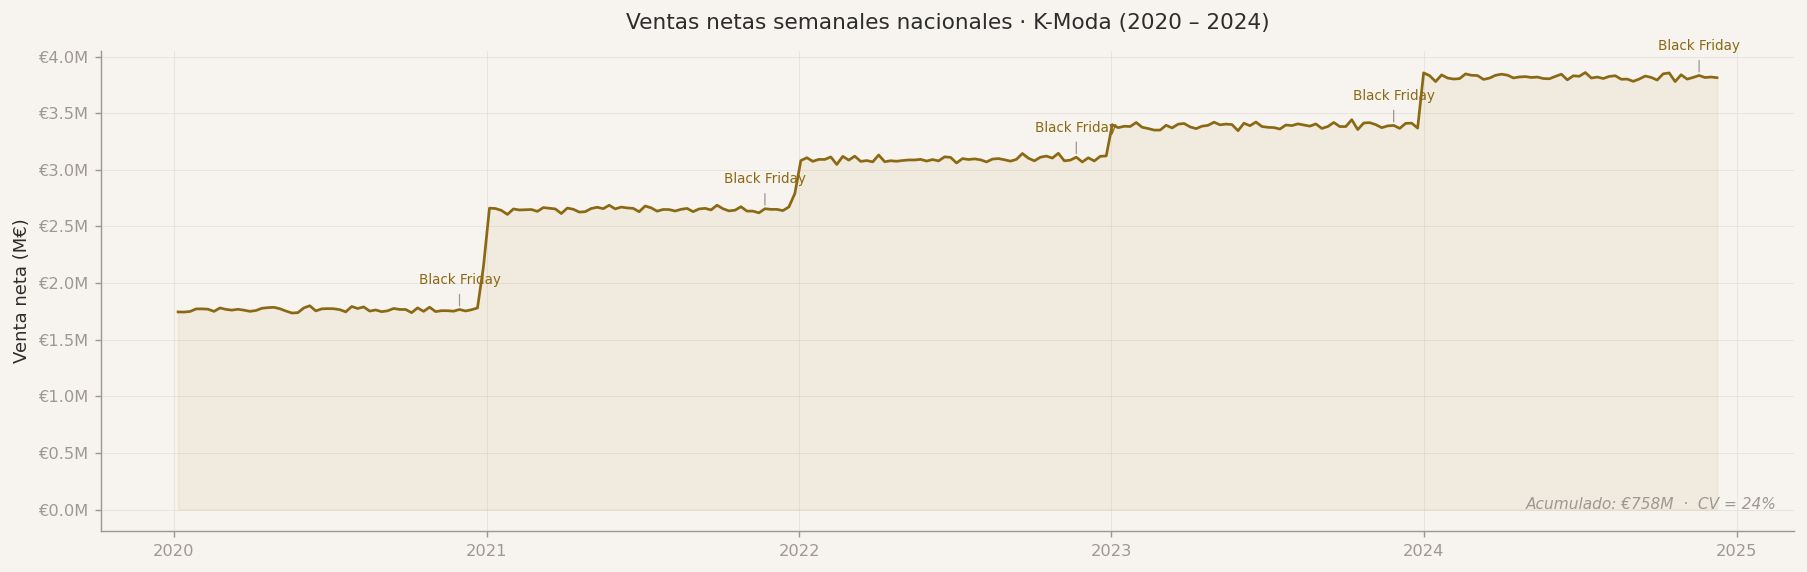

In [14]:
# ── Gráfica 1: Ventas netas semanales nacionales ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5))

ax.fill_between(master["semana_inicio"], master["venta_neta_total_eur"],
                alpha=0.12, color=KM_GOLD)
ax.plot(master["semana_inicio"], master["venta_neta_total_eur"],
        color=KM_GOLD_DARK, linewidth=1.5)

# Un punto por año: la semana de máxima venta dentro del período Black Friday
bf_peak = (
    master[master["black_friday_flag"] == 1]
    .groupby(master["anio"])
    .apply(lambda g: g.loc[g["venta_neta_total_eur"].idxmax()])
    .reset_index(drop=True)
)
for _, row in bf_peak.iterrows():
    ax.annotate("Black Friday", xy=(row["semana_inicio"], row["venta_neta_total_eur"]),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=7.5, color=KM_GOLD_DARK,
                arrowprops=dict(arrowstyle="-", color=KM_GRAY, lw=0.7))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Ventas netas semanales nacionales · K-Moda (2020 – 2024)")
ax.set_ylabel("Venta neta (M€)")

total = master["venta_neta_total_eur"].sum()
cv    = master["venta_neta_total_eur"].std() / master["venta_neta_total_eur"].mean()
ax.text(0.99, 0.04, f"Acumulado: €{total/1e6:.0f}M  ·  CV = {cv:.0%}",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=8.5, color=KM_GRAY, style="italic")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "g1_ventas_semanales.png"), dpi=150)
plt.show()

### Gráfica 2 · Escalones anuales y elección del target

**Izquierda**: el nivel medio anual sube cada año en escalones discretos (+30–50 % entre 2020 y 2021).
**Derecha**: `Yt_scaled` (÷ 1M€) mantiene CV = 22 %, suficiente para que ElasticNet atribuya ventas
a los canales. `Yt_indexed` colapsa el CV al ~1.5 % y purga los coeficientes.

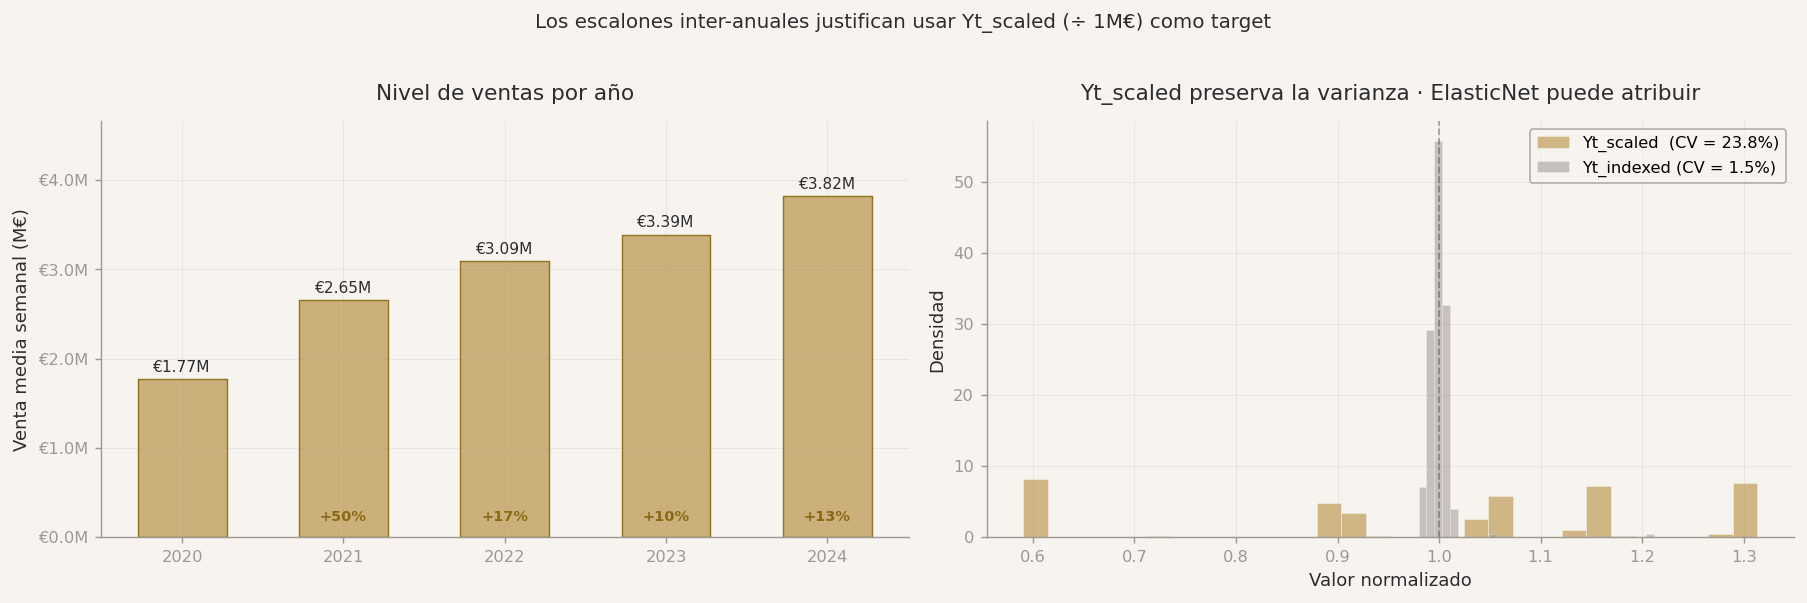

In [15]:
# ── Gráfica 2: Escalones anuales + comparación de CV ─────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 4.5))

# ─ Izquierda: venta media por año ────────────────────────────────────────────
annual = master.groupby("anio")["venta_neta_total_eur"].mean()
ax_l.bar(annual.index, annual.values / 1e6,
         color=KM_GOLD, width=0.55, alpha=0.9,
         edgecolor=KM_GOLD_DARK, linewidth=0.8)
for yr, val in annual.items():
    ax_l.text(yr, val/1e6 + 0.05, f"€{val/1e6:.2f}M",
              ha="center", va="bottom", fontsize=8.5, color=KM_CHARCOAL)
for yr, pct in (annual.pct_change() * 100).items():
    if not pd.isna(pct):
        ax_l.text(yr, 0.15, f"+{pct:.0f}%",
                  ha="center", va="bottom", fontsize=8,
                  color=KM_GOLD_DARK, fontweight="bold")
ax_l.set_ylabel("Venta media semanal (M€)")
ax_l.set_title("Nivel de ventas por año")
ax_l.set_xticks(annual.index)
ax_l.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.1f}M"))
ax_l.set_ylim(0, annual.max()/1e6 * 1.22)

# ─ Derecha: distribución Yt_scaled vs Yt_indexed ─────────────────────────────
cv_sc  = master["Yt_scaled"].std()  / master["Yt_scaled"].mean()
cv_idx = master["Yt_indexed"].std() / master["Yt_indexed"].mean()
yt_sc_norm = master["Yt_scaled"] / master["Yt_scaled"].mean()

ax_r.hist(yt_sc_norm, bins=30, color=KM_GOLD, alpha=0.82,
          edgecolor=KM_CREAM, linewidth=0.3,
          label=f"Yt_scaled  (CV = {cv_sc:.1%})", density=True)
ax_r.hist(master["Yt_indexed"], bins=30, color=KM_GRAY, alpha=0.55,
          edgecolor=KM_CREAM, linewidth=0.3,
          label=f"Yt_indexed (CV = {cv_idx:.1%})", density=True)
ax_r.axvline(1.0, color=KM_CHARCOAL, linewidth=1, linestyle="--", alpha=0.4)
ax_r.set_xlabel("Valor normalizado")
ax_r.set_ylabel("Densidad")
ax_r.set_title("Yt_scaled preserva la varianza · ElasticNet puede atribuir")
ax_r.legend()

fig.suptitle("Los escalones inter-anuales justifican usar Yt_scaled (÷ 1M€) como target",
             fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "g2_escalones_y_cv.png"), dpi=150)
plt.show()

### Gráfica 3 · Inversión semanal por canal de medios

Área apilada de los 8 canales `inv_*`. Permite identificar qué canales dominan el presupuesto
y si hay estacionalidad o discontinuidades en el gasto que afectarían al adstock.

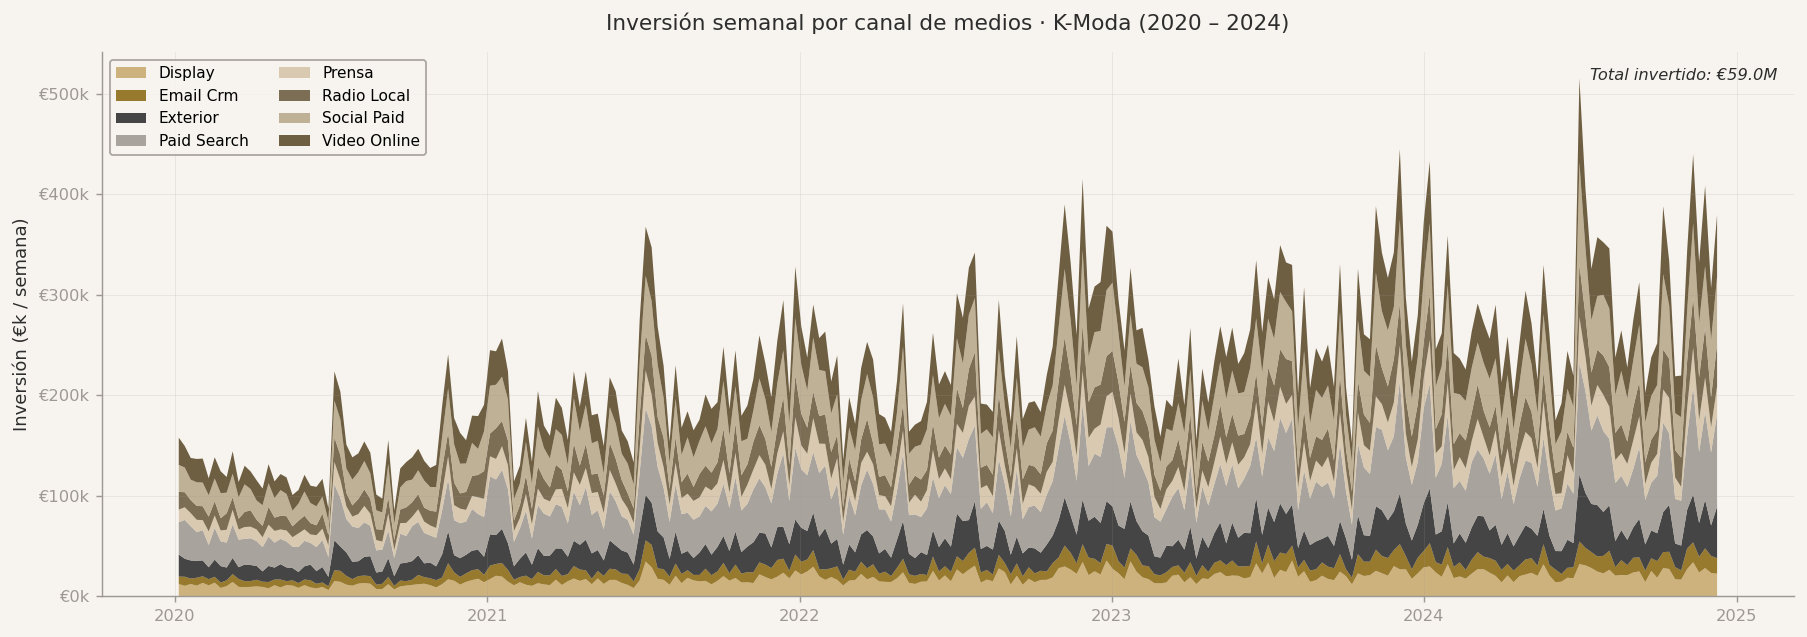

In [16]:
# ── Gráfica 3: Inversión semanal por canal ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

inv_cols = [c for c in master.columns if c.startswith("inv_") and c != "inversion_total_eur"]
inv_data = [master[c].values for c in inv_cols]
labels   = [c.replace("inv_", "").replace("_", " ").title() for c in inv_cols]

ax.stackplot(master["semana_inicio"], inv_data,
             labels=labels, colors=KM_CHANNELS[:len(inv_cols)], alpha=0.88)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e3:.0f}k"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Inversión semanal por canal de medios · K-Moda (2020 – 2024)")
ax.set_ylabel("Inversión (€k / semana)")
ax.legend(loc="upper left", ncol=2, fontsize=8.5, framealpha=0.85)

total_inv = master["inversion_total_eur"].sum()
ax.text(0.99, 0.97, f"Total invertido: €{total_inv/1e6:.1f}M",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color=KM_CHARCOAL, style="italic")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "g3_inversion_canales.png"), dpi=150)
plt.show()

### Gráfica · Inversión en medios: visión completa por canal individual

Panel de análisis de inversión sobre los **8 canales individuales** (antes de agrupar).
Muestra la distribución acumulada, la evolución anual, la serie semanal y el mix porcentual
estable a lo largo del período — lo que justifica usar priors fijos de adstock.

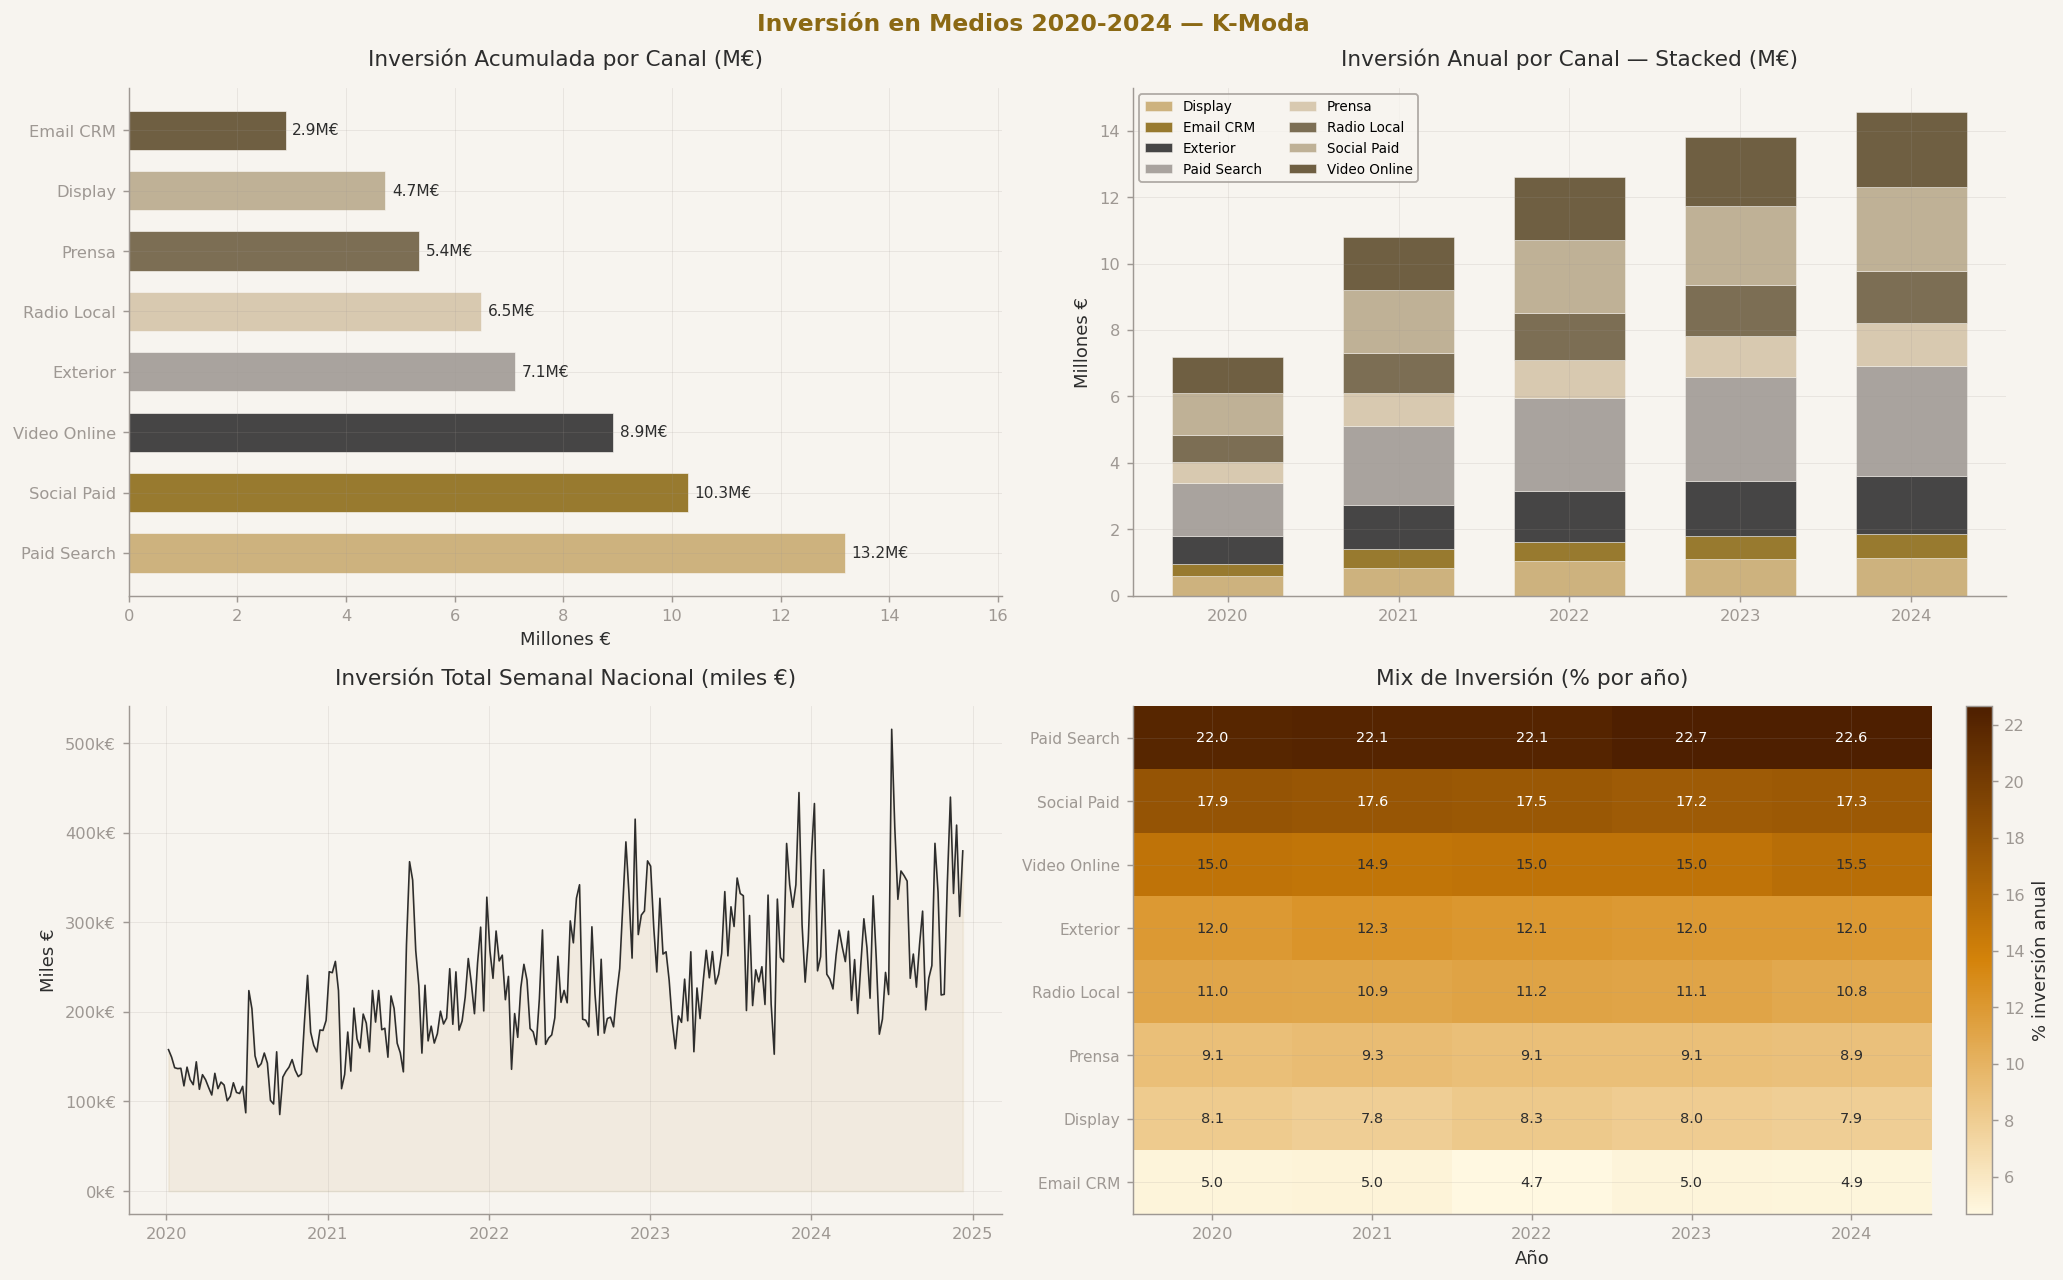

In [17]:
# ── Inversión en Medios 2020-2024 — vista completa por canal ─────────────────
from matplotlib.colors import LinearSegmentedColormap

INV_COLS_8 = sorted([c for c in master.columns
                     if c.startswith("inv_") and c != "inversion_total_eur"])
CH_NAMES   = {
    "inv_display":      "Display",
    "inv_email_crm":    "Email CRM",
    "inv_exterior":     "Exterior",
    "inv_paid_search":  "Paid Search",
    "inv_prensa":       "Prensa",
    "inv_radio_local":  "Radio Local",
    "inv_social_paid":  "Social Paid",
    "inv_video_online": "Video Online",
}
YEARS = sorted(master["anio"].unique())
cmap_warm = LinearSegmentedColormap.from_list("km_warm", ["#FFF8E1", "#D4830A", "#4E1F00"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Inversión en Medios 2020-2024 — K-Moda",
             fontsize=13, color=KM_GOLD_DARK, fontweight="bold")

# ─ Top-left: acumulado por canal (horizontal bar) ─────────────────────────────
ax = axes[0, 0]
totals_ch = {CH_NAMES[c]: master[c].sum() / 1e6 for c in INV_COLS_8}
sorted_ch  = sorted(totals_ch.items(), key=lambda x: x[1], reverse=True)
lbl, val   = zip(*sorted_ch)
colors_bar = KM_CHANNELS[:len(lbl)]
bars = ax.barh(list(lbl), list(val), color=colors_bar, alpha=0.88, height=0.65,
               edgecolor=KM_CREAM, lw=0.4)
for bar, v in zip(bars, val):
    ax.text(v + 0.12, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}M€", va="center", fontsize=8.5, color=KM_CHARCOAL)
ax.set_xlabel("Millones €")
ax.set_title("Inversión Acumulada por Canal (M€)")
ax.set_xlim(0, max(val) * 1.22)

# ─ Top-right: stacked bar anual ───────────────────────────────────────────────
ax = axes[0, 1]
annual = {c: [master[master["anio"] == yr][c].sum() / 1e6 for yr in YEARS]
          for c in INV_COLS_8}
bottom = [0.0] * len(YEARS)
for i, c in enumerate(INV_COLS_8):
    ax.bar(YEARS, annual[c], bottom=bottom, color=KM_CHANNELS[i],
           label=CH_NAMES[c], alpha=0.88, edgecolor=KM_CREAM, lw=0.3, width=0.65)
    bottom = [b + v for b, v in zip(bottom, annual[c])]
ax.set_ylabel("Millones €")
ax.set_title("Inversión Anual por Canal — Stacked (M€)")
ax.legend(ncol=2, fontsize=7.5, loc="upper left",
          framealpha=0.8, edgecolor=KM_GRAY)
ax.set_xticks(YEARS)

# ─ Bottom-left: serie semanal total ───────────────────────────────────────────
ax = axes[1, 0]
ax.fill_between(master["semana_inicio"], master["inversion_total_eur"] / 1e3,
                alpha=0.12, color=KM_GOLD)
ax.plot(master["semana_inicio"], master["inversion_total_eur"] / 1e3,
        color=KM_CHARCOAL, lw=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k€"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Miles €")
ax.set_title("Inversión Total Semanal Nacional (miles €)")

# ─ Bottom-right: mix % por canal × año (heatmap) ─────────────────────────────
ax = axes[1, 1]
ch_sorted_by_pct = [c for c, _ in sorted(
    {c: master[c].sum() / master[INV_COLS_8].sum().sum() for c in INV_COLS_8}.items(),
    key=lambda x: x[1], reverse=True
)]
mix = np.array([
    [master[master["anio"] == yr][c].sum() /
     master[master["anio"] == yr][INV_COLS_8].sum().sum() * 100
     for yr in YEARS]
    for c in ch_sorted_by_pct
])
im = ax.imshow(mix, cmap=cmap_warm, aspect="auto",
               vmin=mix.min(), vmax=mix.max(), interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% inversión anual")
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels(YEARS)
ax.set_yticks(range(len(ch_sorted_by_pct)))
ax.set_yticklabels([CH_NAMES[c] for c in ch_sorted_by_pct], fontsize=8.5)
ax.set_xlabel("Año")
ax.set_title("Mix de Inversión (% por año)")
for i, c in enumerate(ch_sorted_by_pct):
    for j, yr in enumerate(YEARS):
        v  = mix[i, j]
        tc = "white" if v > 16 else KM_CHARCOAL
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color=tc)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "inversion_medios_overview.png"), dpi=150)
plt.show()

### Gráfica 4 · Calendario comercial

Presencia semanal de los 7 eventos nacionales. Black Friday y Rebajas son puntuales y se solapan
con los picos de ventas — serán covariables clave en el modelo.

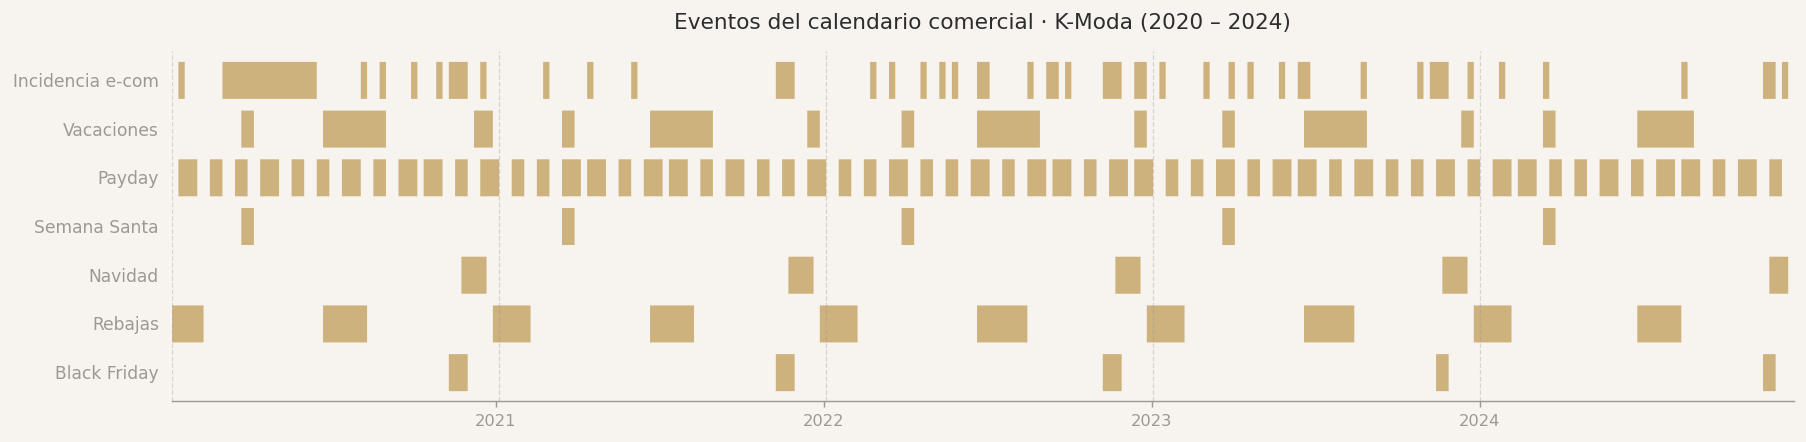

In [18]:
# ── Gráfica 4: Eventos del calendario comercial ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))

FLAG_LABELS = [
    ("black_friday_flag",         "Black Friday"),
    ("rebajas_flag",              "Rebajas"),
    ("navidad_flag",              "Navidad"),
    ("semana_santa_flag",         "Semana Santa"),
    ("payday_flag",               "Payday"),
    ("vacaciones_escolares_flag", "Vacaciones"),
    ("incidencia_ecommerce_flag", "Incidencia e-com"),
]
n = len(FLAG_LABELS)

for i, (flag, _) in enumerate(FLAG_LABELS):
    s = master[flag].values.astype(float)
    ax.fill_between(master["semana_inicio"],
                    i - s * 0.38, i + s * 0.38,
                    step="pre", color=KM_GOLD, alpha=0.88, linewidth=0)

ax.set_yticks(range(n))
ax.set_yticklabels([lbl for _, lbl in FLAG_LABELS], fontsize=9.5)
ax.set_ylim(-0.6, n - 0.4)
ax.set_xlim(master["semana_inicio"].min(),
            master["semana_inicio"].max() + pd.Timedelta(days=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title("Eventos del calendario comercial · K-Moda (2020 – 2024)")
ax.spines["left"].set_visible(False)
ax.grid(False)
ax.tick_params(axis="y", left=False)

for yr in master["anio"].unique():
    start = master[master["anio"] == yr]["semana_inicio"].min()
    ax.axvline(start, color=KM_GRAY, linewidth=0.7, alpha=0.35, linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "g4_calendario.png"), dpi=150)
plt.show()

### Gráfica 5 · Validación del target y señal MMM

**Izquierda**: `Yt_indexed` muestra distribuciones similares entre años → el split estratificado
por año es válido para evaluación. **Derecha**: ventas e inversión total co-varían (r > 0) →
hay señal explotable para el modelo de atribución.

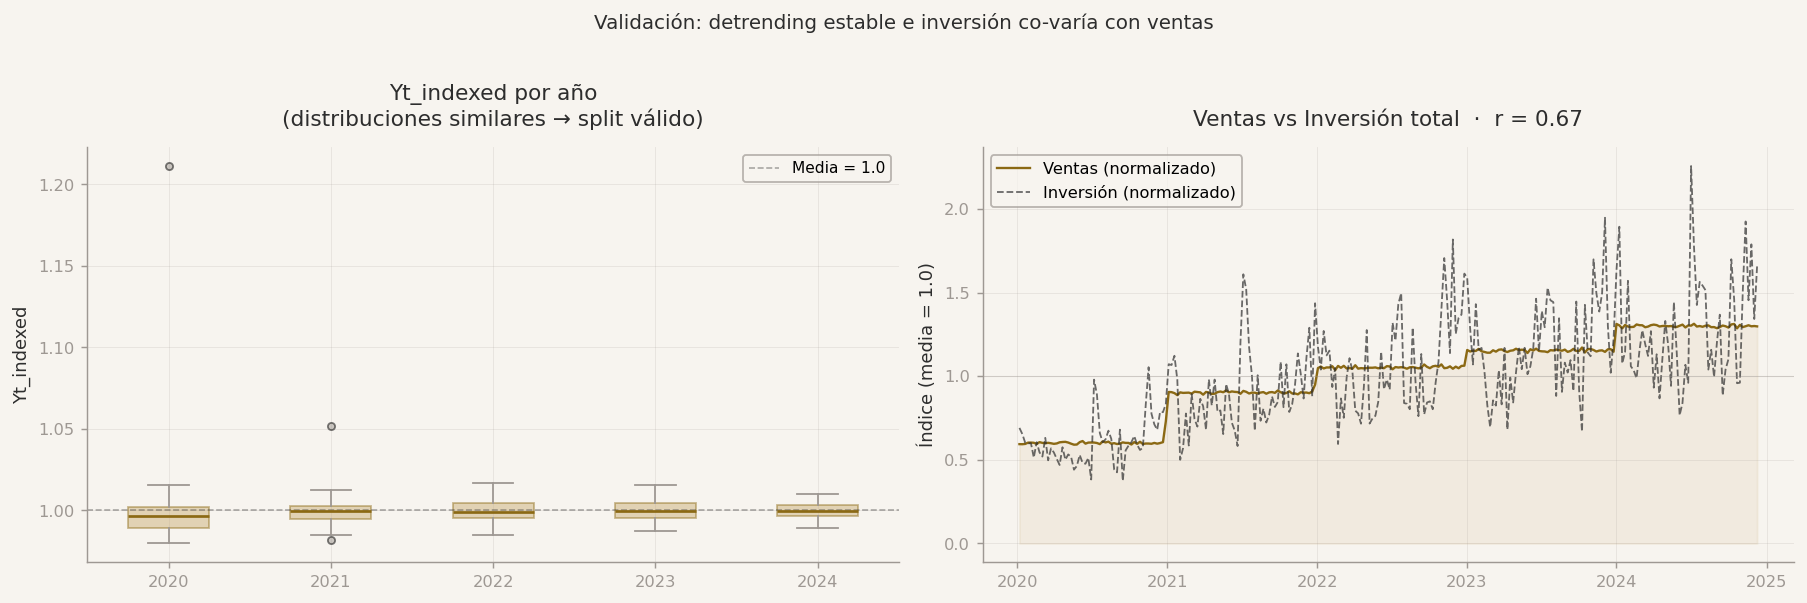

In [19]:
# ── Gráfica 5: Validación del detrending y señal del modelo ──────────────────
fig, (ax_box, ax_line) = plt.subplots(1, 2, figsize=(14, 4.5))

# ─ Izquierda: Yt_indexed por año (boxplot) ───────────────────────────────────
data_by_year = [master.loc[master["anio"] == yr, "Yt_indexed"].values
                for yr in sorted(master["anio"].unique())]
bp = ax_box.boxplot(
    data_by_year, labels=sorted(master["anio"].unique()),
    patch_artist=True, widths=0.5,
    medianprops=dict(color=KM_GOLD_DARK, linewidth=1.5),
    whiskerprops=dict(color=KM_GRAY, linewidth=1),
    capprops=dict(color=KM_GRAY, linewidth=1),
    flierprops=dict(marker="o", markerfacecolor=KM_GRAY,
                    markersize=4, alpha=0.5, linestyle="none"),
)
for patch in bp["boxes"]:
    patch.set_facecolor(KM_GOLD)
    patch.set_alpha(0.45)
    patch.set_edgecolor(KM_GOLD_DARK)
ax_box.axhline(1.0, color=KM_CHARCOAL, linewidth=0.9, linestyle="--",
               alpha=0.4, label="Media = 1.0")
ax_box.set_ylabel("Yt_indexed")
ax_box.set_title("Yt_indexed por año\n(distribuciones similares → split válido)")
ax_box.legend(fontsize=8.5)
ax_box.tick_params(axis="x", labelsize=9)

# ─ Derecha: ventas vs inversión total (normalizado) ──────────────────────────
inv_cols  = [c for c in master.columns if c.startswith("inv_") and c != "inversion_total_eur"]
inv_total = master[inv_cols].sum(axis=1)
inv_norm  = inv_total / inv_total.mean()
yt_norm   = master["venta_neta_total_eur"] / master["venta_neta_total_eur"].mean()
r = np.corrcoef(master["venta_neta_total_eur"], inv_total)[0, 1]

ax_line.fill_between(master["semana_inicio"], yt_norm, alpha=0.12, color=KM_GOLD)
ax_line.plot(master["semana_inicio"], yt_norm,
             color=KM_GOLD_DARK, linewidth=1.3, label="Ventas (normalizado)")
ax_line.plot(master["semana_inicio"], inv_norm,
             color=KM_CHARCOAL, linewidth=1.0, linestyle="--", alpha=0.7,
             label="Inversión (normalizado)")
ax_line.axhline(1.0, color=KM_GRAY, linewidth=0.6, alpha=0.35)
ax_line.set_ylabel("Índice (media = 1.0)")
ax_line.set_title(f"Ventas vs Inversión total  ·  r = {r:.2f}")
ax_line.legend(loc="upper left")
ax_line.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_line.xaxis.set_major_locator(mdates.YearLocator())

fig.suptitle("Validación: detrending estable e inversión co-varía con ventas",
             fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "g5_validacion.png"), dpi=150)
plt.show()

## 11. Guardar

In [20]:
OUTPUT_PATH = os.path.join(OUT_DIR, "etl.csv")
master.to_csv(OUTPUT_PATH, index=False)

print(f"✓ Guardado: {OUTPUT_PATH}")
print(f"  Shape   : {master.shape}")
print(f"  Tamaño  : {os.path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

✓ Guardado: data/warehouse/version1/etl.csv
  Shape   : (258, 50)
  Tamaño  : 132.8 KB
